### Team Members:


In [138]:
# Importing our packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm

# Loading our movies dataset
movies = pd.read_csv("tmdb_5000_movies.csv")

# Introduction

The film industry is a high-risk, high-reward environment where production budgets can range from thousands to hundreds of millions of dollars. Despite the availability of historical data, predicting whether a movie will be financially successful remains a challenging problem. Studios must make investment decisions before release, often relying on incomplete or uncertain information.

In this project, we aim to use data-driven techniques to better understand what factors contribute to a movie’s financial success. By leveraging historical movie data, we can identify patterns and build predictive models that may assist in decision-making.

### Project Goal

The primary goal of this project is to classify whether a movie is a financial <strong>hit</strong> or  <strong>flop</strong> based on its characteristics. Rather than using raw revenue as a measure of success, we define success using Return on Investment (ROI): 
$$
ROI = \frac{Revenue - Budget}{Budget}
$$
Using ROI provides a more meaningful measure of financial performance, as it accounts for the scale of investment. 

Therefore, we will:
- Engineer relevant features from the dataset
- Define a threshold to classify movies as “hits” or “flops”
- Build and compare multiple classification models
- Use cross-validation and regularization to optimize model performance
- Interpret which factors most strongly influence success

### Data Description

The dataset used in this project is the TMDB 5000 Movies Dataset, which contains information on 4803 movies.

Key features include:

- Budget and Revenue
- Genres (categorical, multi-label)
- Runtime
- Popularity
- Vote average and vote count
- Production companies and countries

The dataset requires preprocessing, as several columns are stored as nested JSON strings and must be parsed and transformed into usable features.

In [139]:
# Dimensions of our dataset
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

### Data Cleaning and Preprocessing

In [140]:
movies.isnull().sum().sort_values(ascending=False)

homepage                3091
tagline                  844
overview                   3
runtime                    2
release_date               1
id                         0
budget                     0
genres                     0
original_title             0
popularity                 0
original_language          0
keywords                   0
production_countries       0
production_companies       0
spoken_languages           0
revenue                    0
status                     0
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [141]:
# Drop irrelevant columns from our dataframe
columns_to_drop = ['homepage', 'id', 'overview', 'tagline', 'title', 'keywords', 'spoken_languages', 'release_date', 'original_language', 'status']
movies = movies.drop(columns=columns_to_drop)

In [142]:
# Remove movies with no budget and revenue since they are not useful
movies = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)]

# Drop remaining missing values
movies = movies.dropna()

In [143]:
# Function to extract names from JSON-like strings using regex.
def extract_names(column_str: str) -> list[str]:
    if pd.isna(column_str):
        return []
    return re.findall(r'"name"\s*:\s*"([^"]+)"', column_str)

In [144]:
json_columns = ['genres', 'production_companies', 'production_countries']

for col in json_columns:
    movies[col] = movies[col].apply(extract_names)

In [145]:
# ROI calculation
movies['ROI'] = (movies['revenue'] - movies['budget']) / movies['budget']

In [146]:
# Define success based on the ROI using 1.5 based on information found online for films (1.5 is slightly higher than the median in our data)
movies['success'] = (movies['ROI'] > 1.5).astype(int)

In [147]:
# Filter out movies with ROI > 10 (There were five films with ROI > 1000). Some were due to incorrect budget values in data set 
# but others were indie films that had massive success (Blair Witch Project or Paranormal Activity)
movies = movies[movies['ROI'] < 10]

In [148]:
movies.head(5)

,budget,genres,original_title,popularity,production_companies,production_countries,revenue,runtime,vote_average,vote_count,ROI,success
1,300000000,"[Adventure, Fantasy, Action]",Pirates of the Caribbean: At World's End,139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",[United States of America],961000000,169.0,6.9,4500,2.203333,1
2,245000000,"[Action, Adventure, Crime]",Spectre,107.376788,"[Columbia Pictures, Danjaq, B24]","[United Kingdom, United States of America]",880674609,148.0,6.3,4466,2.594590,1
3,250000000,"[Action, Crime, Drama, Thriller]",The Dark Knight Rises,112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",[United States of America],1084939099,165.0,7.6,9106,3.339756,1
4,260000000,"[Action, Adventure, Science Fiction]",John Carter,43.926995,[Walt Disney Pictures],[United States of America],284139100,132.0,6.1,2124,0.092843,0
5,258000000,"[Fantasy, Action, Adventure]",Spider-Man 3,115.699814,"[Columbia Pictures, Laura Ziskin Productions, ...",[United States of America],890871626,139.0,5.9,3576,2.452991,1


# Exploratory Data Analysis

In this section, we explore the dataset to identify patterns and relationships that may influence a movie’s financial success. In particular, we focus on the distribution of ROI, the relationship between budget and revenue, and how success varies across genres.

In [149]:
sns.set_style("whitegrid")

### ROI Distribution

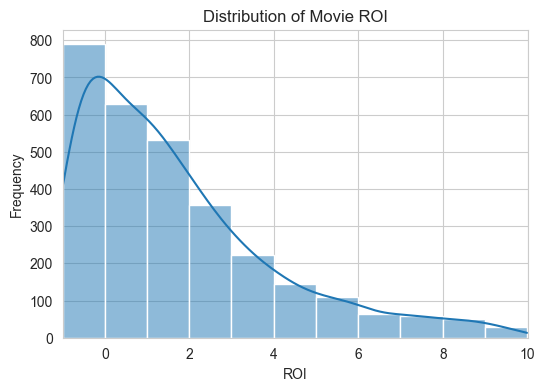

In [150]:
plt.figure(figsize=(6, 4))
sns.histplot(movies['ROI'], bins=11, kde=True)

plt.title("Distribution of Movie ROI")
plt.xlabel("ROI")
plt.ylabel("Frequency")

plt.xlim(-1, 10)
plt.show()

The distribution of ROI is right-skewed with most movies clustered around negative (-1 to 0) or low/moderate (0 to 2) returns, and an increasingly smaller number achieving very high (6-10). profitability. These results indicate that a significant proportion of films fail due to inherent risk in movie production. However, when a movie succeeds, there is an opportunity for returns to be magnitudes higher than the initial budget.

### Budget vs Revenue

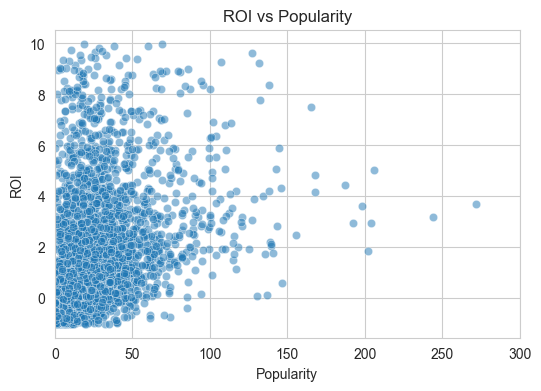

In [161]:
plt.figure(figsize=(6, 4))

sns.scatterplot(x=movies['popularity'], y=movies['ROI'], alpha=0.5)

plt.title("ROI vs Popularity")
plt.xlabel("Popularity")
plt.ylabel("ROI")

plt.xlim(0, 300)
plt.show()

The relationship between popularity and ROI appears to be weakly positive but highly dispersed. While more popular movies tend to achieve higher returns on average, there is significant variability, indicating that popularity alone is not a strong predictor of financial success. This suggests that popularity may contribute useful signal in modeling, but should be combined with other features for better predictive performance.

### Top 10 Genres by Average ROI

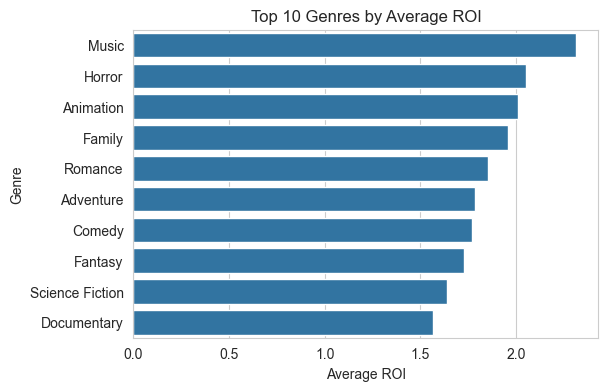

In [152]:
# Gives each genre its own row for movies with multiple genres
genres_exploded = movies.explode('genres')

# Group genre_exploded by ROI and then calculate the mean before sorting them in descending order
genre_roi = (
    genres_exploded.groupby('genres')['ROI']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=genre_roi.head(10).values,
    y=genre_roi.head(10).index
)
plt.title("Top 10 Genres by Average ROI")
plt.xlabel("Average ROI")
plt.ylabel("Genre")

plt.show()

Average ROI varies noticeably across genres. Genres such as Music, Horror, and Animation tend to exhibit higher average returns, while others show more moderate performance. This suggests that genre plays a meaningful role in financial success and may be an important feature in predictive modeling.

### Feature Engineering

To improve model performance and better capture the factors influencing movie success, we construct several new features from the original dataset. These features are designed to incorporate fi

In [153]:
# Number of genres that will help capture how broad the movie is
movies['num_genres'] = movies['genres'].apply(len)

# Number of production companies involved with the movie
movies['num_production_companies'] = movies['production_companies'].apply(len)

# Number of countries involved in the production of the movie
movies['num_countries'] = movies['production_countries'].apply(len)

In [154]:
genres_exploded = movies[['genres']].explode('genres')
genre_dummies = pd.get_dummies(genres_exploded['genres'])

# Aggregate back to movie level
genre_dummies = genre_dummies.groupby(level=0).max()

# Merge back into original dataframe
movies = pd.concat([movies, genre_dummies], axis=1)

Several features were constructed to enhance the predictive power of the models. We created numerical features capturing structural aspects of each film, including the number of genres, production companies, and production countries, which reflect the scope and scale of a movie’s production.

Additionally, since movies can belong to multiple genres, the genres column was transformed by expanding the genre lists and creating binary indicators for each genre, allowing the model to capture genre-specific effects on financial success.

# Modelling

In [158]:
# Remove columns we will not need before beginning the modelling section
movies_model = movies.drop(columns=[
    'genres',
    'budget',
    'revenue',
    'production_companies',
    'production_countries',
    'original_title'  # keep in main df, but remove for modeling
])
movies_model

,popularity,runtime,vote_average,vote_count,ROI,success,num_genres,num_production_companies,num_countries,Action,...,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
1,139.082615,169.0,6.9,4500,2.203333,1,3,3,1,True,...,False,False,False,False,False,False,False,False,False,False
2,107.376788,148.0,6.3,4466,2.594590,1,3,3,2,True,...,False,False,False,False,False,False,False,False,False,False
3,112.312950,165.0,7.6,9106,3.339756,1,4,4,1,True,...,False,False,False,False,False,False,False,True,False,False
4,43.926995,132.0,6.1,2124,0.092843,0,3,1,1,True,...,False,False,False,False,False,False,True,False,False,False
5,115.699814,139.0,5.9,3576,2.452991,1,3,3,1,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4752,2.380332,99.0,5.6,59,5.407662,1,3,1,1,False,...,False,False,False,False,False,True,False,False,False,False
4758,27.662696,95.0,5.8,631,-0.849776,0,2,3,1,False,...,False,False,False,False,False,False,True,True,False,False
4772,1.330379,89.0,6.3,26,-0.679405,0,3,0,1,True,...,False,False,False,False,False,False,False,False,False,False
4792,0.212443,111.0,7.4,63,3.950000,1,4,1,1,False,...,False,False,True,False,True,False,False,True,False,False


In [ ]:
# Define X and y variables for our model
X = movies_model.drop(columns=['success', 'ROI'])
y = movies_model['success']

# Conclusion